# Resumen

Cambio de dinámica espacio-temporal en los meses de verano. Demostrando que usar mismo modelo para temporada baja que alta sería un error.

**Existe ligera autocorrelación espacial dependiendo del tiempo en el target**: más probable en verano alquilar en sitios concretos, contrario en invierno que es irrelevante

**Comportamiento aleatorio en verano para precios**: posible fruto de la demanda en verano, donde pisos con precios baratos conviven con precios caros estando próximos en el espacio, cuando el resto del año se tiende a la débil agrupación en precios.

**Comportamiento de ligera agrupación en verano en reviews**: todo el año no depende del barrio en la review, menos en verano donde hay un débil cambio de tendencia. 

# 0. Conexión con proyecto e importación de dataset

In [8]:
%load_ext autoreload
%autoreload 2

from spatial_temporal import *

warnings.filterwarnings("ignore", module="statsmodels.tsa.stattools")
warnings.filterwarnings('ignore')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
df = gpd.read_parquet(r"D:\yannis_data\Descargas\airbnb_bcn_clean.parquet")
df_barrios = pd.read_csv(r"D:\yannis_data\Descargas\BarcelonaCiutat_Barris.csv")

In [9]:
# 1. Crear el GeoDataFrame manteniendo EPSG:4326 
distritos_gdf = gpd.GeoDataFrame(
    df_barrios, 
    geometry=gpd.points_from_xy(df_barrios.longitude, df_barrios.latitude) if 'lat' in df_barrios else df_barrios['geometria_wgs84'].apply(wkt.loads),
    crs="EPSG:4326")

# 2. Asegurar de que la columna se llame 'geometry' y sea la activa
distritos_gdf = distritos_gdf.set_geometry('geometry')

# 3. Normalizar usando el mismo nombre que espera tu función 
distritos_gdf['key_spatial'] = distritos_gdf['nom_barri'].str.lower().str.strip()

# 4. Agrupar puntos
conteo_barrios = df.groupby('neighbourhood_cleansed').size().reset_index(name='count')
conteo_barrios['key_spatial'] = conteo_barrios['neighbourhood_cleansed'].str.lower().str.strip()

# 5. Merge 
gdf_mapa = distritos_gdf.merge(conteo_barrios, on='key_spatial', how='inner')

In [10]:
# 1. Convertir la columna de texto WKT a objetos geométricos reales
if not isinstance(df_barrios['geometria_wgs84'].iloc[0], (str, bytes)) == False:
    geometrias = df_barrios['geometria_wgs84'].apply(wkt.loads)
else:
    geometrias = df_barrios['geometria_wgs84']

# 2. CREAR EL GEODATAFRAME (Esto es lo que falta para que tenga .crs)
df_barrios = gpd.GeoDataFrame(df_barrios, geometry=geometrias, crs="EPSG:4326")

# 3. Asegurarnos de que la columna se llame 'geometry'
df_barrios = df_barrios.set_geometry('geometry')

df_barrios = df_barrios.drop(columns=['geometria_etrs89', 'geometria_wgs84'], errors='ignore')

# 1. Componente espacio temporal

## 1.1 Variable target


[+] Generando Coropletas por periodo para: is_occupied...


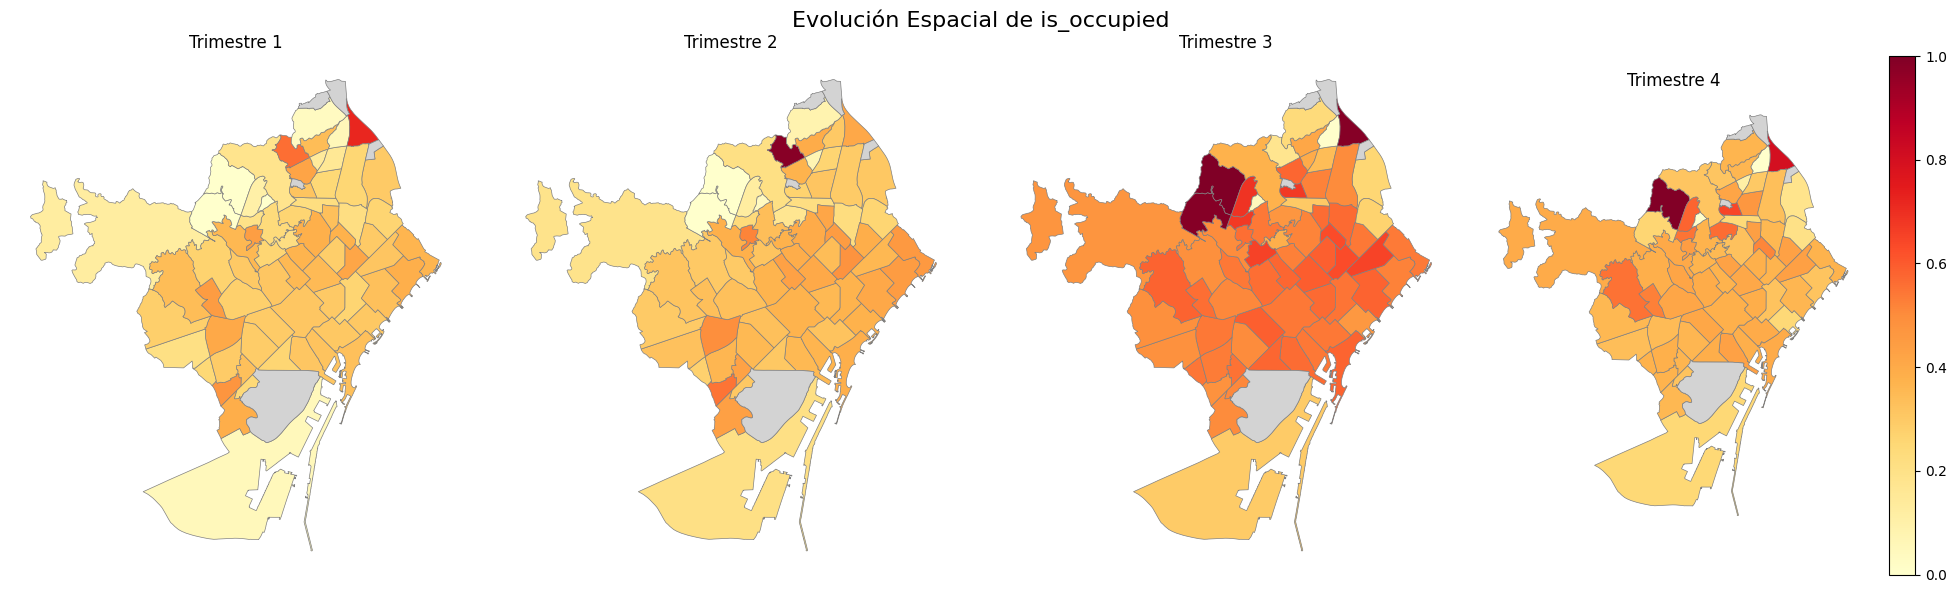


[+] Calculando Índice de Moran mensual para: is_occupied...


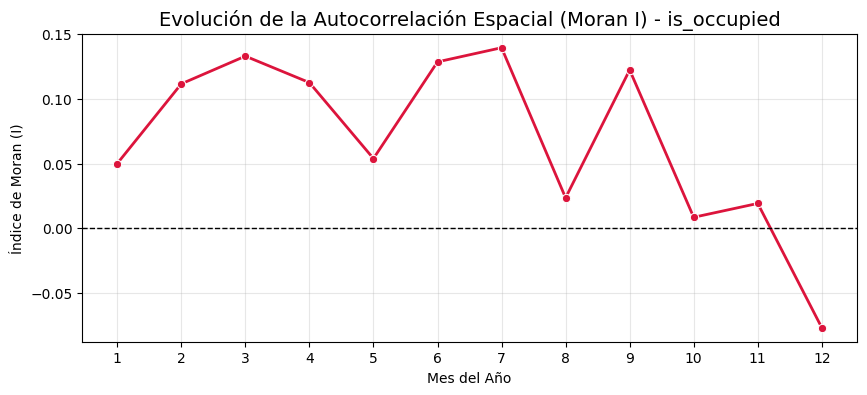

In [14]:
variable_target = ['is_occupied']

for var in variable_target:
    
    # Despliegue de Mapas Trimestrales (Small Multiples)
    plot_choropleths_by_period(df, df_barrios, var, period_col='month')
    
    # Dispersión Autorregresiva en el Tiempo (Trackeo de Moran)
    plot_moran_over_time(df, df_barrios, var)

## 1.2 Variables predictoras


[+] Generando Coropletas por periodo para: listing_price...


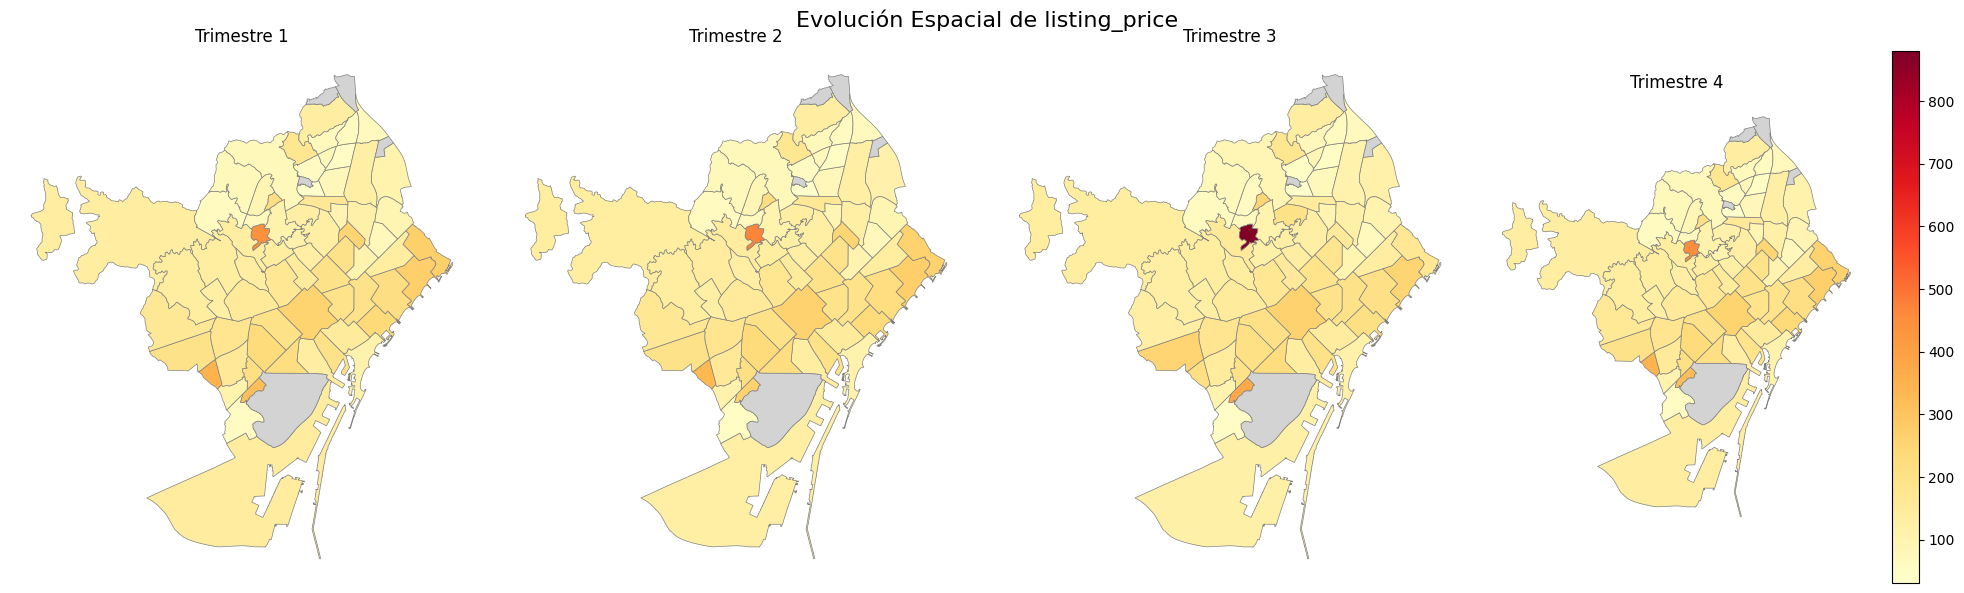


[+] Calculando Índice de Moran mensual para: listing_price...


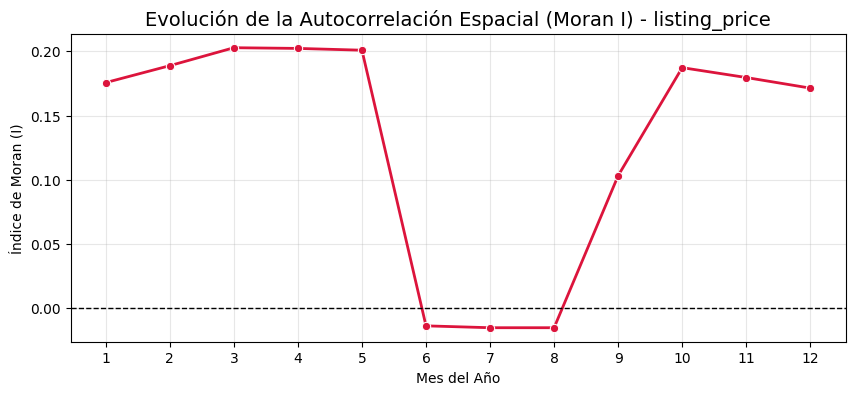


[+] Generando Coropletas por periodo para: review_scores_rating...


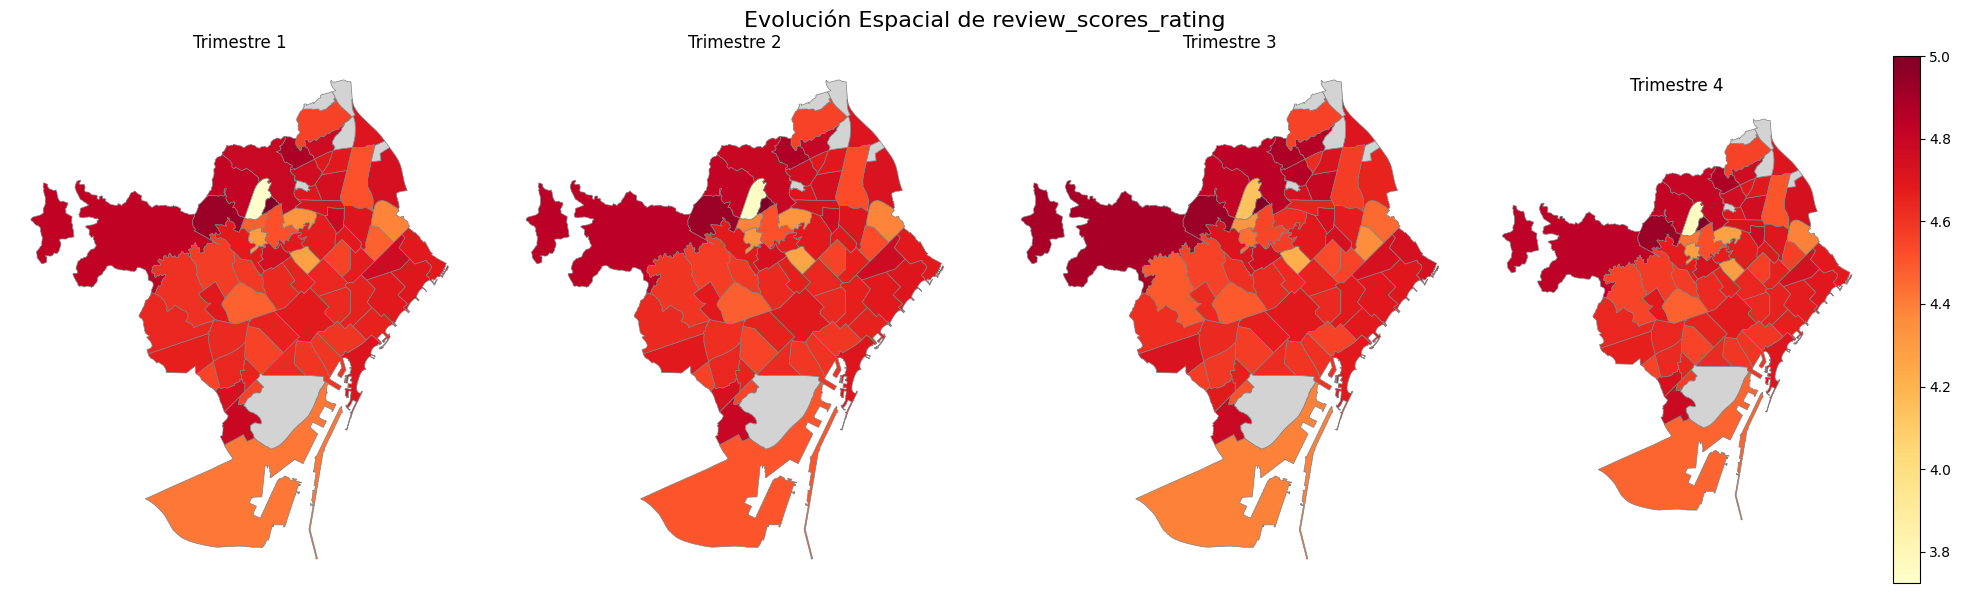


[+] Calculando Índice de Moran mensual para: review_scores_rating...


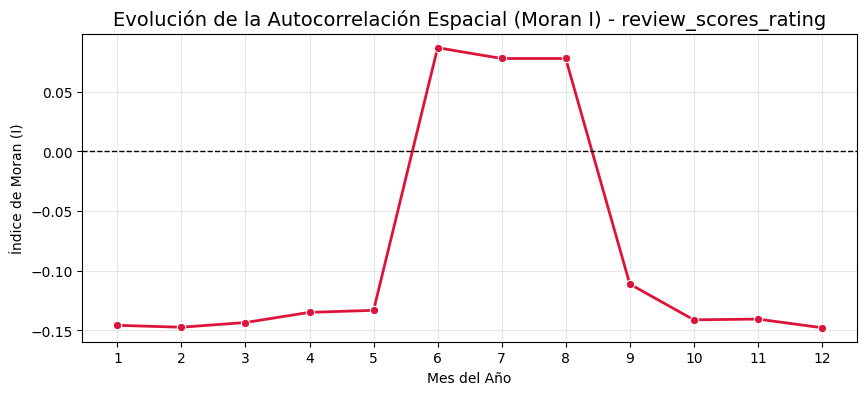

In [15]:
variables_analisis = [ 'listing_price', 'review_scores_rating']

for var in variables_analisis:

    # Despliegue de Mapas Trimestrales (Small Multiples)
    plot_choropleths_by_period(df, df_barrios, var, period_col='month')
    
    # Dispersión Autorregresiva en el Tiempo (Moran)
    plot_moran_over_time(df, df_barrios, var)